Tugas Praktik: Klasifikasi dengan Logistic Regression

Tujuan: Melakukan praktik klasifikasi menggunakan algoritma Logistic Regression untuk menyelesaikan permasalahan pada dataset pilihan

Nama Anggota:

Muhammad Abdillah Mutashim (24523239)

ibrahim ivanka(24523279 )

Muhamad Aldio Khairullah Santoso(24523250)

**Persiapan Library dan Dataset**


Langkah pertama adalah mengimpor library yang diperlukan dan memuat dataset. Kita menggunakan dataset Iris karena sesuai untuk kasus klasifikasi




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_iris

# Memahami dataset dan target klasifikasi (Ketentuan poin 3a)
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("5 Data Pertama:")
print(df.head())

5 Data Pertama:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


**Preprocessing dan Pembagian Data**

Sebelum melatih model, kita perlu memastikan data siap digunakan dan membaginya menjadi data training dan testing.

In [ ]:
# Preprocessing data (Ketentuan poin 3b)
X = df.drop('target', axis=1)
y = df['target']

# Pembagian data training dan testing (Ketentuan poin 3c)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 120
Jumlah data testing: 30


**Membangun Model Logistic Regression**

Pada tahap ini, kita akan menginisialisasi algoritma Logistic Regression dan melatihnya menggunakan data training

In [ ]:
# Membangun model (Ketentuan poin 3d)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

**Evaluasi Model: Classification Report**

Berikut adalah hasil evaluasi model untuk melihat performa presisi, recall, dan f1-score.

In [ ]:
# Menampilkan Classification Report (Ketentuan poin 4)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Evaluasi Model: Confusion Matrix**

Confusion Matrix digunakan untuk melihat seberapa banyak data yang diprediksi dengan benar atau salah untuk setiap kelas

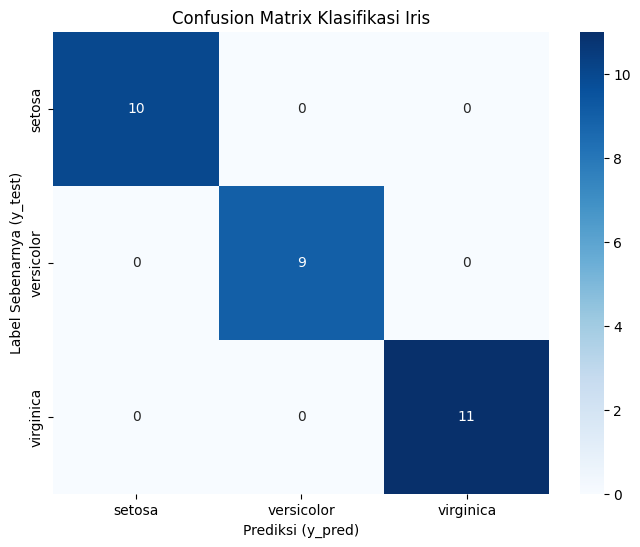

In [ ]:
# Visualisasi Confusion Matrix (Ketentuan poin 4)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Prediksi (y_pred)')
plt.ylabel('Label Sebenarnya (y_test)')
plt.title('Confusion Matrix Klasifikasi Iris')
plt.show()

**contoh Hasil Prediksi**

Berikut adalah perbandingan antara label asli (y_test) dengan hasil prediksi model (y_pred).

In [ ]:
# Menampilkan contoh hasil prediksi (Ketentuan poin 5)
comparison = pd.DataFrame({'Label Sebenarnya': y_test, 'Hasil Prediksi': y_pred})
mapping = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
print(comparison.head(10).replace(mapping))

    Label Sebenarnya Hasil Prediksi
73        Versicolor     Versicolor
18            Setosa         Setosa
118        Virginica      Virginica
78        Versicolor     Versicolor
76        Versicolor     Versicolor
31            Setosa         Setosa
64        Versicolor     Versicolor
141        Virginica      Virginica
68        Versicolor     Versicolor
82        Versicolor     Versicolor


**Analisis dan Kesimpulan**

1.Kinerja Model: Berdasarkan classification report, model memiliki akurasi yang sangat tinggi. Nilai precision dan recall mendekati 1.0, yang menunjukkan model sangat handal dalam mengklasifikasikan spesies bunga.  

2.Makna TP, FP, TN, FN (Contoh Setosa):

True Positive (TP): Diprediksi Setosa, aslinya memang Setosa.  

False Positive (FP): Diprediksi Setosa, aslinya spesies lain.  

True Negative (TN): Diprediksi bukan Setosa, aslinya memang bukan Setosa.  

False Negative (FN): Diprediksi bukan Setosa, padahal aslinya Setosa.  

3.Kesimpulan:
Logistic Regression bekerja sangat baik pada dataset ini karena dataset memiliki pemisah antar kelas yang cukup linier
